# Análisis Exploratorio de Datos (EDA)

## Contexto y Origen del Dataset

El presente Análisis Exploratorio de Datos (EDA) tiene como objetivo comprender la estructura, distribución y características del dataset utilizado para el entrenamiento del modelo de clasificación de texto del proyecto NoetIA.

La información contenida en este conjunto de datos proviene de múltiples fuentes:

- Tareas personales registradas en mi día a día.
- Ejemplos generados con apoyo de herramientas de Inteligencia Artificial para ampliar la variabilidad lingüística.
- Tareas proporcionadas voluntariamente por amigos y familiares.
  
Es importante destacar que todas las personas que contribuyeron con ejemplos otorgaron su consentimiento informado para el uso de su información con fines estrictamente académicos. Asimismo, los datos fueron anonimizados y no contienen información sensible.

El dataset está compuesto por textos breves que representan tareas, recordatorios o notas personales tal como suelen escribirse en entornos reales (por ejemplo, WhatsApp, Notion o anotaciones rápidas). Esta característica es relevante, ya que el modelo deberá aprender patrones semánticos a partir de lenguaje natural cotidiano y no de estructuras formales estandarizadas.

El propósito de este EDA es:

- Evaluar el balance de clases.
- Analizar la longitud y complejidad del texto.
- Identificar patrones léxicos predominantes.
- Detectar posibles sesgos estructurales.
- Comprender la calidad general del conjunto de datos antes de proceder a la etapa de modelado.

Este análisis permitirá fundamentar las decisiones posteriores relacionadas con el entrenamiento y evaluación del modelo.

## 1. Configuración del Notebook

### Preparación del entorno de análisis

En esta sección preparé el entorno de trabajo necesario para desarrollar el análisis exploratorio de datos.

Primero importé las librerías fundamentales para el análisis y visualización, principalmente `pandas` para la manipulación de datos y `matplotlib` para la generación de gráficas. Posteriormente configuré el estilo visual del notebook, asegurando coherencia estética y claridad en la documentación.

También definí la ruta del dataset y cargué el archivo en un DataFrame, que será la estructura principal sobre la cual se realizará todo el análisis.

In [1]:
# Configuración y API
import os
import sys
import json
import time
import re
import unicodedata
from pathlib import Path

raiz_proyecto = Path(os.getcwd()).parent
sys.path.append(str(raiz_proyecto / 'src'))

from dotenv import load_dotenv
from openai import OpenAI
from noetia.config import OPENAI_MODEL

# Manejo de datos y matemáticas
import pandas as pd
import numpy as np
from collections import Counter
from scipy.stats import entropy

# Visualización
import matplotlib.pyplot as plt
import plotly.express as px

# Machine Learning y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
import joblib

# Evaluación del modelo
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix
)

In [2]:
MAR = {
    "bg": "#FAF7F2",          # beige claro
    "ink": "#2C2C2C",         # casi negro
    "muted": "#A8A29E",       # gris suave
    "accent1": "#D4A373",     # caramelo
    "accent2": "#9C89B8",     # lila
    "accent3": "#6D6875",     # gris-morado
    "accent4": "#B5838D",     # rosita viejo
    "accent5": "#83AFA1",     # verde salvia
    "accent6": "#F2CC8F",     # crema dorado
}

plt.rcParams.update({
    "figure.facecolor": MAR["bg"],
    "axes.facecolor": MAR["bg"],
    "axes.edgecolor": MAR["muted"],
    "axes.labelcolor": MAR["ink"],
    "xtick.color": MAR["ink"],
    "ytick.color": MAR["ink"],
    "text.color": MAR["ink"],
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "grid.color": "#E7E1D9",
    "grid.alpha": 0.6,
})


In [ ]:
PATH = "Base_de_datos_NoetIA.csv"

df = pd.read_csv(PATH, encoding='latin-1')

print(df.shape)

(662, 14)


In [6]:
df.head(10)

,id,creado_en,fecha_vencimiento,canal,texto_original,area,tema,intencion,estado,prioridad,longitud_texto,numero_palabras,tiene_pregunta,tiene_fecha
0,1,24/05/2026,20/06/2026,Texto,Cita medica con el nutriologo,Salud,Doctor,Cita,Pendiente,3,29,5,0,0
1,2,10/02/2027,05/03/2027,Texto,Poner gasolina al auto,Entorno Fisico,Mantenimiento,Tarea,Pendiente,3,22,4,0,0
2,3,19/05/2027,15/06/2027,Voz,Entregar presentacion al conmutador para el si...,Trabajo,Gestion de Proyectos,Tarea,Pendiente,1,53,7,0,0
3,4,12/04/2027,02/05/2027,Texto,Pagar tarjeta,Finanzas,Pagos,Tarea,Pendiente,3,13,2,0,0
4,5,09/12/2026,14/12/2026,Voz,Cargar ordenes de trabajo en sistema,Trabajo,Entregables,Tarea,Pendiente,4,36,6,0,0
5,6,16/11/2026,02/12/2026,Texto,Darle de desayunar a los perros,Familia,Responsabilidades,Tarea,Pendiente,4,31,6,0,0
6,7,12/10/2027,19/10/2027,Voz,Jueves: mandar roster del weekend support todo...,Trabajo,Entregables,Tarea,Pendiente,1,58,9,0,0
7,8,07/02/2026,10/02/2026,Texto,Solicitar cita en agencia para servicio de auto.,Entorno Fisico,Tramite,Nota,Pendiente,3,48,8,0,0
8,9,03/04/2027,20/04/2027,Voz,Comprar alimento para mascotas.,Entorno Fisico,Super,Tarea,Pendiente,3,31,4,0,0
9,10,13/05/2027,29/05/2027,Voz,Renovar credencial del super.,Entorno Fisico,Tramite,Nota,Pendiente,1,29,4,0,0


## 2. Información General del Dataset

### Exploración inicial de la estructura de los datos

Una vez cargado el dataset, el siguiente paso fue realizar una inspección general para comprender su estructura, dimensiones y tipos de variables.

En esta sección utilicé funciones como `df.shape`, `df.head()` y `df.info()` para obtener una visión global del conjunto de datos. Esto me permitió identificar:

- El número total de registros.
- La cantidad de columnas disponibles.
- Los tipos de datos asociados a cada variable.
- La presencia de valores nulos.

Esta revisión inicial es fundamental en cualquier análisis exploratorio, ya que permite detectar posibles inconsistencias antes de profundizar en el estudio de las variables.

A partir de esta inspección confirmé que el dataset contiene principalmente variables categóricas asociadas a clasificación (`area`, `intencion`, `canal`, `estado`, etc.) y variables numéricas derivadas del texto (`numero_palabras`, `longitud_texto`, `tiene_fecha`, `tiene_pregunta`).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120067 entries, 0 to 120066
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 120067 non-null  int64 
 1   creado_en          120067 non-null  object
 2   fecha_vencimiento  120067 non-null  object
 3   canal              120067 non-null  object
 4   texto_original     120067 non-null  object
 5   area               120067 non-null  object
 6   tema               120067 non-null  object
 7   intencion          120067 non-null  object
 8   estado             120067 non-null  object
 9   prioridad          120067 non-null  object
 10  longitud_texto     120067 non-null  int64 
 11  numero_palabras    120067 non-null  int64 
 12  tiene_pregunta     120067 non-null  int64 
 13  tiene_fecha        120067 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 12.8+ MB


**Comentario**

El dataset tiene 120,067 registros y 14 columnas, lo cual es una cantidad sólida para entrenar un modelo de clasificación de texto.

No hay valores nulos en ninguna variable, lo que significa que los datos están completos y no requieren limpieza inicial. Esto facilita el análisis y permite enfocarme directamente en entender el comportamiento del texto.

La mayoría de las columnas son categóricas, lo cual tiene sentido porque el objetivo del proyecto es clasificar tareas por área e intención. Las columnas numéricas corresponden a métricas derivadas del texto, como número de palabras y longitud, además de indicadores binarios.

Las fechas están guardadas como texto (`object`), pero por ahora no es un problema, ya que el modelo se entrenará únicamente con la variable `texto_original`.

En general, el dataset está ordenado, consistente y listo para comenzar el análisis exploratorio.

In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

id                   0
creado_en            0
fecha_vencimiento    0
canal                0
texto_original       0
area                 0
tema                 0
intencion            0
estado               0
prioridad            0
longitud_texto       0
numero_palabras      0
tiene_pregunta       0
tiene_fecha          0
dtype: int64

**Comentario**

No existen valores nulos en el dataset.  
Esto confirma que los datos están completos y listos para el análisis sin necesidad de limpieza previa.

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,120067.0,NaN,NaN,NaN,60034.0,34660.501723,1.0,30017.5,60034.0,90050.5,120067.0
creado_en,120067,5516,2026-02-17T00:00:00,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_vencimiento,120067,5416,2026-02-06T13:00:00,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,120067,5,notion,24244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
texto_original,120067,88592,Nota sobre Pendientes: revisar pendientes y pr...,404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,120067,12,Salud,10167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tema,120067,62,Oración,2598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intencion,120067,4,crear_tarea,66088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado,120067,4,Terminada,30337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prioridad,120067,4,Baja,30252,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Comentario**

Este resumen estadístico me permite entender con mayor claridad con qué tipo de información estoy trabajando antes de avanzar al modelado.

Confirmo que el dataset está compuesto por 12 áreas distintas, lo cual está directamente alineado con la estructura de mi proyecto, basada en el concepto de las 12 áreas de vida. Esto es importante porque el modelo no solo busca clasificar texto, sino organizar tareas dentro de una visión integral de vida.

También observo que la intención `crear_tarea` es la más frecuente. Esto es lógico, ya que la mayoría de los ejemplos provienen de tareas reales del día a día. Sin embargo, es un punto que debo considerar, ya que podría influir en el comportamiento del modelo.

El hecho de contar con 88,592 textos únicos me da tranquilidad sobre la diversidad del lenguaje. Aunque el dataset fue construido con apoyo de IA y con tareas proporcionadas por amigos y familiares, esta variedad sugiere que no estoy trabajando únicamente con frases repetidas.

En cuanto a la longitud del texto, confirmo que las tareas son cortas, directas y naturales, tal como normalmente se escriben en aplicaciones como WhatsApp o Notion. Esto es coherente con el objetivo del proyecto.

Al tratarse de un dataset armado, es esperado que tenga una estructura limpia y controlada. Sin embargo, precisamente por haber sido construido con apoyo externo (IA y personas reales), este análisis me permite evaluar qué tan variado es el lenguaje y detectar posibles patrones demasiado estructurados que podrían afectar el entrenamiento.

En resumen, este primer vistazo me ayuda a validar que el dataset refleja la lógica de las 12 áreas de vida y que cuento con una base suficientemente amplia para comenzar el análisis más profundo.

### Conteos básicos

In [8]:
df["area"].value_counts()

area
Salud                   10167
Espiritualidad          10107
Carrera                 10083
Dinero                  10073
Recreación              10027
Comunidad               10011
Crecimiento Personal     9989
Hogar                    9957
Apariencia               9954
Familia                  9928
Amor                     9903
Amigos                   9868
Name: count, dtype: int64

In [9]:
df["intencion"].value_counts(normalize=True) * 100

intencion
crear_tarea         55.042601
actualizar_tarea    20.041310
nota                14.900014
pregunta            10.016074
Name: proportion, dtype: float64

In [10]:
df["canal"].value_counts()

canal
notion      24244
sms         24079
voz         24063
whatsapp    23888
gmail       23793
Name: count, dtype: int64

**Comentario**

A partir de los conteos básicos puedo entender cómo se distribuyen las principales variables categóricas del dataset.

En el caso de `area`, confirmo que las 12 áreas de vida están representadas en el conjunto de datos. Esto es clave para mi proyecto, ya que el modelo deberá aprender a clasificar tareas dentro de esta estructura integral de organización personal.

Al revisar la variable `intencion`, observo que la mayoría de los registros corresponden a `crear_tarea`. Esto es lógico, ya que la fuente principal del dataset son tareas reales del día a día. Sin embargo, esta concentración puede generar un desbalance que influya en el aprendizaje del modelo si no se considera más adelante.

En cuanto a `canal`, puedo identificar desde qué contexto se generan más tareas (por ejemplo, Notion o WhatsApp). Esto me ayuda a entender el origen del lenguaje utilizado y cómo puede variar el estilo de redacción dependiendo del medio.

Estos conteos me permiten validar que el dataset sigue la lógica del proyecto (12 áreas de vida) y, al mismo tiempo, me ayudan a detectar posibles concentraciones que podrían afectar el comportamiento del modelo.

## 3. Análisis Visual del Dataset

### Comprensión visual de la distribución de los datos

Después de revisar los conteos básicos, decidí visualizar la información mediante gráficas para entender de forma más intuitiva cómo están distribuidos los datos y qué implicaciones puede tener esto en el entrenamiento del modelo.

Las visualizaciones me permiten identificar patrones que no siempre son evidentes en tablas numéricas, como concentraciones, desbalances o comportamientos atípicos.

En esta sección analizo principalmente:

- La distribución de las áreas de vida.
- La proporción de cada tipo de intención.
- La frecuencia de los canales de origen.
- La longitud de los textos.
- La presencia de referencias temporales o preguntas.

Estas gráficas me ayudan a responder preguntas clave antes de modelar:

- ¿Existe un desbalance fuerte entre clases?
- ¿El texto es demasiado corto o demasiado estructurado?
- ¿Algunas categorías dominan el dataset?
- ¿El modelo podría aprender patrones demasiado obvios?

Dado que el objetivo del proyecto es entrenar un modelo basado únicamente en `texto_original`, entender la estructura y distribución del lenguaje es fundamental. Una buena exploración visual me permite anticipar posibles riesgos y tomar decisiones informadas en la siguiente etapa del proyecto.

### 3.1 Top 12 Áreas de Vida

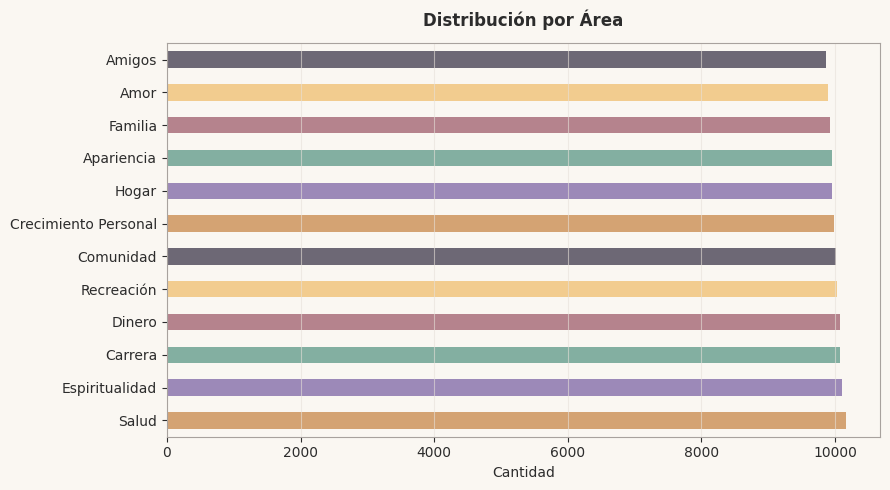

In [11]:
counts = df["area"].value_counts()

plt.figure(figsize=(9, 5))
colors = [MAR["accent1"], MAR["accent2"], MAR["accent5"], MAR["accent4"], MAR["accent6"], MAR["accent3"]] * 3
counts.plot(kind="barh", color=colors[:len(counts)])
plt.title("Distribución por Área")
plt.xlabel("Cantidad")
plt.ylabel("")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


**Comentario:**
La gráfica muestra la distribución de registros por cada una de las 12 áreas de vida definidas en el proyecto.

A simple vista puedo observar que las áreas se encuentran bastante equilibradas entre sí, sin una categoría que domine de manera significativa sobre las demás. Esto es especialmente importante considerando que el modelo deberá aprender a clasificar tareas dentro de esta estructura.

Dado que el dataset fue construido intencionalmente con base en las 12 áreas de vida (inspiradas en la organización integral del proyecto), es lógico que exista una distribución balanceada. Sin embargo, validar esto visualmente me permite confirmar que el modelo no estará expuesto a un sesgo fuerte hacia una sola categoría.

Este equilibrio favorece el entrenamiento, ya que el modelo tendrá suficiente representación de cada área para aprender patrones semánticos diferenciados.

Además, esta gráfica refuerza que la estructura conceptual del proyecto (organizar la vida en 12 dimensiones) está correctamente reflejada en los datos.

### 3.2 Distribución de la Intención

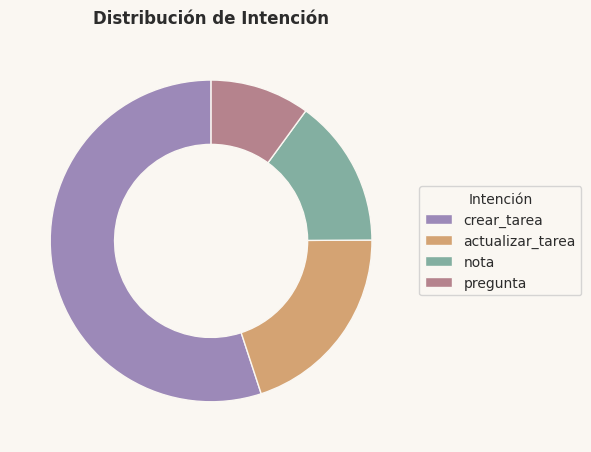

In [12]:
vals = df["intencion"].value_counts()
labels = vals.index.tolist()
colors = [MAR["accent2"], MAR["accent1"], MAR["accent5"], MAR["accent4"]][:len(vals)]

plt.figure(figsize=(6, 6))
wedges, texts = plt.pie(vals, colors=colors, startangle=90, wedgeprops=dict(width=0.4, edgecolor=MAR["bg"]))
plt.title("Distribución de Intención")
plt.legend(wedges, labels, title="Intención", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


**Comentario:**
Esta gráfica muestra cómo se distribuyen los distintos tipos de intención dentro del dataset: `crear_tarea`, `actualizar_tarea`, `nota` y `pregunta`.

Puedo observar que la intención predominante es `crear_tarea`, lo cual tiene sentido considerando que la mayoría de los ejemplos provienen de tareas reales del día a día. En menor proporción aparecen `actualizar_tarea`, `nota` y finalmente `pregunta`.

Este comportamiento es coherente con el objetivo del proyecto, ya que el modelo está orientado principalmente a organizar tareas. Sin embargo, también me permite identificar un posible desbalance entre clases, especialmente en el caso de `pregunta`, que representa una proporción menor del dataset.

Desde el punto de vista del entrenamiento, esto implica que el modelo podría tender a predecir con mayor facilidad la clase dominante si no se controla adecuadamente. Por ello, aunque el dataset fue construido intencionalmente, esta visualización me ayuda a anticipar posibles ajustes futuros.

En resumen, la gráfica confirma que el foco principal del dataset está en la creación de tareas, pero también incluye variabilidad suficiente para modelar distintos tipos de intención.

### 3.3 Longitud del texto

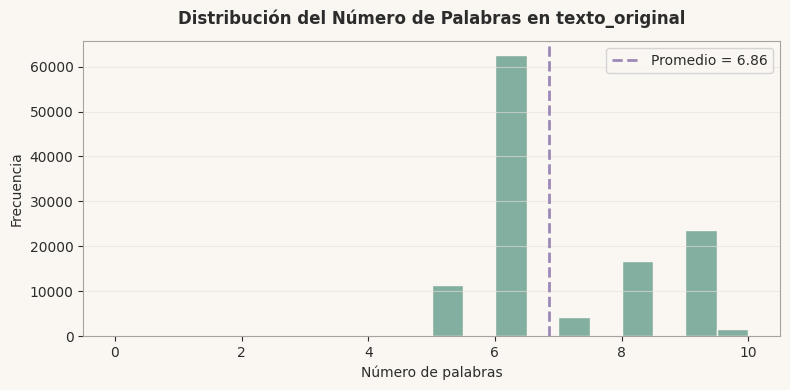

In [13]:
x = df["numero_palabras"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(x, bins=20, color=MAR["accent5"], edgecolor=MAR["bg"])
plt.axvline(x.mean(), linestyle="--", linewidth=2, color=MAR["accent2"], label=f"Promedio = {x.mean():.2f}")
plt.title("Distribución del Número de Palabras en texto_original")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()


**comentario:**
La distribución del número de palabras muestra que la mayoría de los textos se concentran entre 6 y 8 palabras, con un promedio aproximado de 6.86 palabras por registro.

Esto confirma que el dataset está compuesto principalmente por tareas cortas y directas, similares a cómo naturalmente escribimos recordatorios en el día a día. No se trata de párrafos largos ni descripciones extensas, sino de frases concretas y accionables.

Desde la perspectiva del modelo, esto es relevante porque implica que el aprendizaje se basará en señales semánticas muy compactas. Es decir, pocas palabras deberán contener suficiente información para determinar el área y la intención.

La brevedad del texto también reduce ruido innecesario, pero al mismo tiempo aumenta la dificultad, ya que el modelo tendrá menos contexto disponible para clasificar correctamente.

#### Longitud promedio por Área

In [14]:
df.groupby("area")["numero_palabras"].mean().sort_values()

area
Dinero                  6.774546
Carrera                 6.784588
Espiritualidad          6.787672
Amigos                  6.791042
Comunidad               6.791230
Apariencia              6.791642
Amor                    6.797536
Recreación              6.803231
Hogar                   6.821633
Crecimiento Personal    6.963660
Familia                 7.054190
Salud                   7.148815
Name: numero_palabras, dtype: float64

**Comentario**:
Al analizar el número promedio de palabras por cada área, observo que las diferencias son relativamente pequeñas. La mayoría de las áreas se encuentran alrededor de las 6.7 a 7 palabras por tarea.

Sin embargo, áreas como `Salud` y `Familia` presentan ligeramente mayor longitud promedio, mientras que `Dinero` y `Carrera` tienden a ser un poco más concisas.

Esto podría indicar que ciertas dimensiones de la vida requieren mayor nivel de detalle al redactar tareas, mientras que otras suelen expresarse de manera más directa y estructurada.

Desde el punto de vista del entrenamiento, esta homogeneidad en la longitud es positiva, ya que evita que el modelo utilice únicamente la cantidad de palabras como señal para clasificar. En otras palabras, la diferenciación entre áreas deberá basarse principalmente en el contenido semántico y no en la extensión del texto.

Este hallazgo refuerza que el dataset mantiene coherencia estructural entre categorías, lo cual favorece un aprendizaje más equilibrado.

#### Número de Palabras por Intención

C:\Users\marie\AppData\Local\Temp\ipykernel_25796\238777009.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(groups, labels=labels, patch_artist=True, showfliers=False)


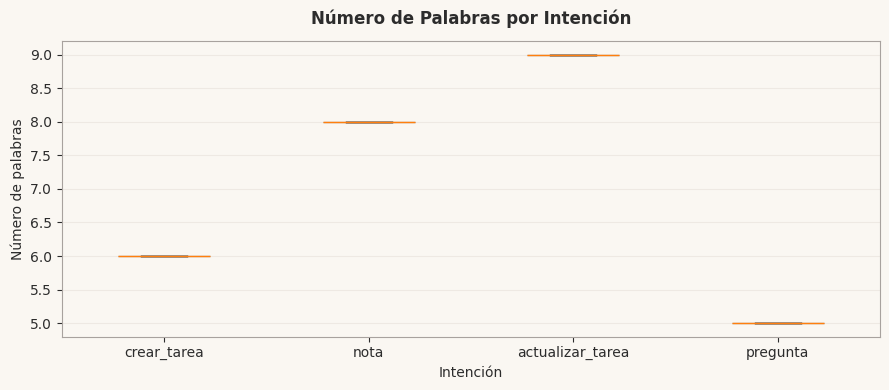

In [15]:
groups = [df.loc[df["intencion"] == k, "numero_palabras"].dropna() for k in df["intencion"].unique()]
labels = df["intencion"].unique().tolist()

plt.figure(figsize=(9, 4))
bp = plt.boxplot(groups, labels=labels, patch_artist=True, showfliers=False)

fill = [MAR["accent1"], MAR["accent2"], MAR["accent5"], MAR["accent4"]] * 2
for patch, c in zip(bp["boxes"], fill):
    patch.set_facecolor(c)
    patch.set_edgecolor(MAR["muted"])

plt.title("Número de Palabras por Intención")
plt.xlabel("Intención")
plt.ylabel("Número de palabras")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


**Comentario:**
En esta visualización analizo cómo varía la cantidad de palabras dependiendo del tipo de intención.

Observo que las tareas clasificadas como `actualizar_tarea` y `nota` tienden a tener ligeramente más palabras en promedio, mientras que `crear_tarea` y especialmente `pregunta` suelen ser más cortas.

Esto tiene sentido desde el comportamiento natural del lenguaje. Cuando se actualiza una tarea o se escribe una nota, normalmente se agrega más contexto. En cambio, las preguntas y la creación de tareas suelen ser más directas.

Desde la perspectiva del modelo, este hallazgo es importante porque confirma que existen pequeñas diferencias estructurales entre las intenciones. Sin embargo, estas diferencias no son lo suficientemente grandes como para que el modelo pueda clasificar únicamente basándose en la longitud del texto.

Esto me indica que el aprendizaje deberá centrarse principalmente en el contenido semántico y no solo en métricas simples como el número de palabras.

### 3.4 Análisis Cruzado de Variables

En esta sección analizo la relación entre variables categóricas clave para entender cómo interactúan entre sí dentro del dataset. Este tipo de análisis permite identificar patrones estructurales que no son visibles al observar cada variable por separado.


#### Área vs Intención

<Figure size 1000x500 with 0 Axes>

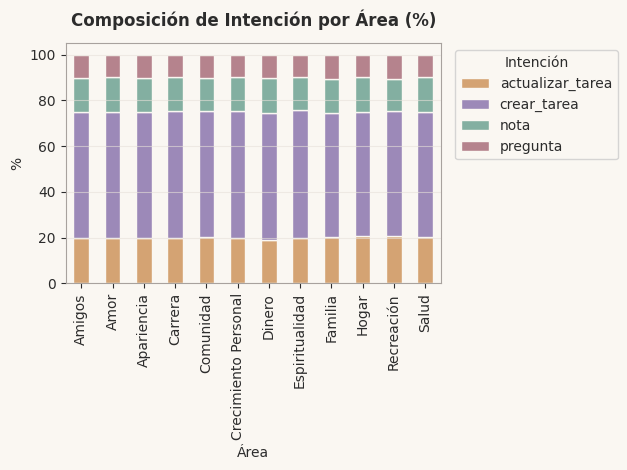

In [16]:
ct = pd.crosstab(df["area"], df["intencion"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100  # porcentaje por área

plt.figure(figsize=(10, 5))
ct_pct.plot(kind="bar", stacked=True,
            color=[MAR["accent1"], MAR["accent2"], MAR["accent5"], MAR["accent4"]],
            edgecolor=MAR["bg"])
plt.title("Composición de Intención por Área (%)")
plt.xlabel("Área")
plt.ylabel("%")
plt.legend(title="Intención", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


**Comentario**:
La gráfica muestra la composición porcentual de cada tipo de intención dentro de las 12 áreas de vida.

Al analizar la distribución, observo que la proporción de `crear_tarea`, `actualizar_tarea`, `nota` y `pregunta` se mantiene relativamente estable entre áreas. No existe una dimensión específica que concentre de manera desproporcionada un tipo de intención particular.

Esto es interesante porque indica que el comportamiento estructural del dataset es consistente entre áreas. Es decir, no hay una categoría que esté asociada casi exclusivamente con un tipo de acción.

Desde la perspectiva del modelo, esto es positivo. Si una sola área estuviera dominada por una única intención, el modelo podría aprender correlaciones superficiales. En cambio, esta distribución homogénea obliga al modelo a enfocarse en el contenido semántico del texto para diferenciar correctamente.

Este resultado confirma que el dataset fue construido de forma equilibrada y que la clasificación no podrá resolverse únicamente mediante patrones estructurales simples.

#### Canal vs Intención

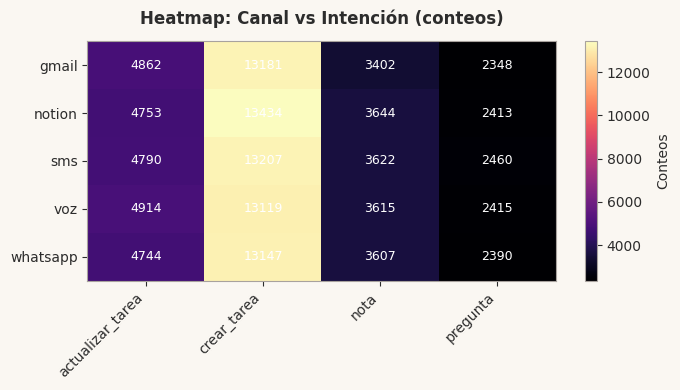

In [17]:
ct2 = pd.crosstab(df["canal"], df["intencion"])
data = ct2.values

plt.figure(figsize=(7, 4))
plt.imshow(data, aspect="auto", cmap="magma")
plt.title("Heatmap: Canal vs Intención (conteos)")
plt.xticks(range(ct2.shape[1]), ct2.columns, rotation=45, ha="right")
plt.yticks(range(ct2.shape[0]), ct2.index)

# números encima
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, int(data[i, j]), ha="center", va="center", color="white", fontsize=9)

plt.colorbar(label="Conteos")
plt.tight_layout()
plt.show()


**Comentario:**
En esta visualización analizo la relación entre el canal de origen y el tipo de intención, utilizando un mapa de calor con conteos absolutos.

Al observar la gráfica, noto que la distribución de intenciones es bastante consistente entre los distintos canales (Gmail, Notion, SMS, voz y WhatsApp). No existe un canal que concentre de forma desproporcionada un tipo específico de intención.

Por ejemplo, `crear_tarea` es la categoría dominante en todos los canales, manteniendo una proporción similar. Lo mismo ocurre con `actualizar_tarea`, `nota` y `pregunta`, cuyos conteos siguen un patrón equilibrado.

Esto es importante porque indica que el modelo no podrá apoyarse únicamente en el canal como una señal indirecta para predecir la intención. Es decir, no hay un sesgo estructural fuerte que vincule un canal específico con una clase determinada.

Desde la perspectiva del entrenamiento, este resultado es positivo, ya que reduce el riesgo de que el modelo aprenda correlaciones superficiales relacionadas con el contexto de captura en lugar del contenido semántico del texto.

En conclusión, el dataset mantiene coherencia estructural entre canal e intención, favoreciendo un aprendizaje más robusto.

### 3.5 Identificación de Palabras y Patrones

En esta sección analizo directamente el contenido del texto para identificar patrones lingüísticos que podrían influir en el entrenamiento del modelo. 

Dado que el modelo se entrenará únicamente con la variable `texto_original`, comprender la estructura del lenguaje es fundamental para anticipar su comportamiento.

#### Textos con referencia temporal

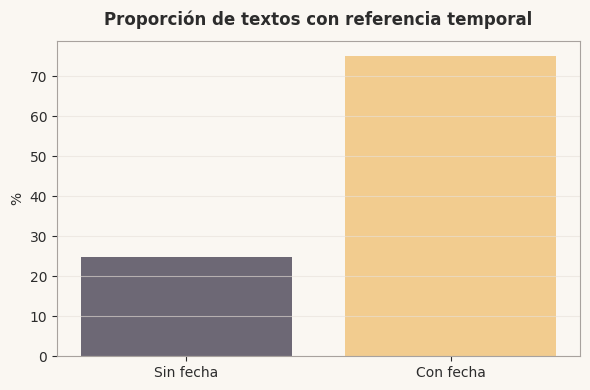

In [18]:
p = df["tiene_fecha"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
plt.bar(["Sin fecha", "Con fecha"], [p.get(0,0), p.get(1,0)], color=[MAR["accent3"], MAR["accent6"]])
plt.title("Proporción de textos con referencia temporal")
plt.ylabel("%")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


**Comentario**:
Al analizar la proporción de textos con referencia temporal, observo que aproximadamente el 75% de las tareas incluyen algún indicador de tiempo explícito, mientras que alrededor del 25% no lo contienen.

Esto me indica que la mayoría de las tareas están estructuradas alrededor de un momento específico (por ejemplo: "lunes", "cada", "diario", "primer domingo", etc.). Esto tiene sentido, ya que gran parte de nuestras actividades están asociadas a fechas o recurrencias.

Sin embargo, desde la perspectiva del entrenamiento del modelo, este patrón es importante. Si una gran proporción del dataset contiene estructuras temporales similares, el modelo podría apoyarse excesivamente en estas palabras clave para clasificar ciertas categorías.

Esto no es necesariamente negativo, pero sí es algo que debo tener presente: el modelo debe aprender el contexto completo del texto y no únicamente identificar marcadores temporales.

En conclusión, el dataset refleja una fuerte organización basada en tiempo, lo cual es coherente con la naturaleza de las tareas, pero también representa una señal estructural que influirá en el aprendizaje.

#### Palabras más frecuentes

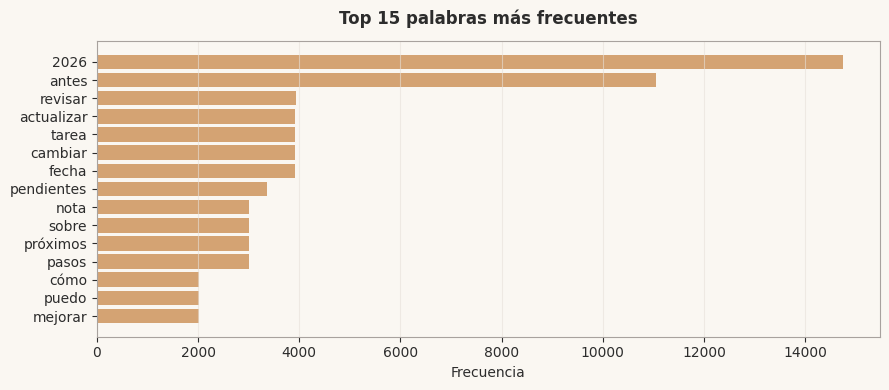

In [19]:
def tokenize_basic(s):
    s = s.lower()
    s = re.sub(r"[^a-záéíóúñü0-9\s:]", " ", s)
    toks = [t for t in s.split() if len(t) > 2]
    return toks

counter = Counter()
for t in df["texto_original"].dropna().sample(20000, random_state=42):  # sample para rapidez
    counter.update(tokenize_basic(t))

top = counter.most_common(15)
words, freqs = zip(*top)

plt.figure(figsize=(9, 4))
plt.barh(words[::-1], freqs[::-1], color=MAR["accent1"])
plt.title("Top 15 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


**Comentario:**
Al analizar las 15 palabras más frecuentes dentro de `texto_original`, observo que muchas están relacionadas con estructura organizativa y temporal.

Palabras como:
- "revisar"
- "actualizar"
- "tarea"
- "cambiar"
- "fecha"
- "pendientes"

refuerzan que el dataset está fuertemente orientado a acciones concretas y gestión de actividades.

También es interesante notar la presencia destacada del año "2026", lo cual es consecuencia directa de la generación estructurada del dataset. Este es un indicador claro de que el modelo podría detectar patrones numéricos asociados a fechas específicas.

Además, aparecen palabras como "cómo", "puedo" y "mejorar", que probablemente están vinculadas a la intención de pregunta o reflexión.

Desde la perspectiva del entrenamiento, este análisis me permite identificar posibles señales dominantes. Si ciertas palabras aparecen con demasiada frecuencia en determinadas áreas o intenciones, el modelo podría depender excesivamente de ellas.

Sin embargo, en general, el vocabulario refleja correctamente el contexto de organización personal y profesional que busca modelar el proyecto.


#### Patrones recurrentes de redacción en el inició

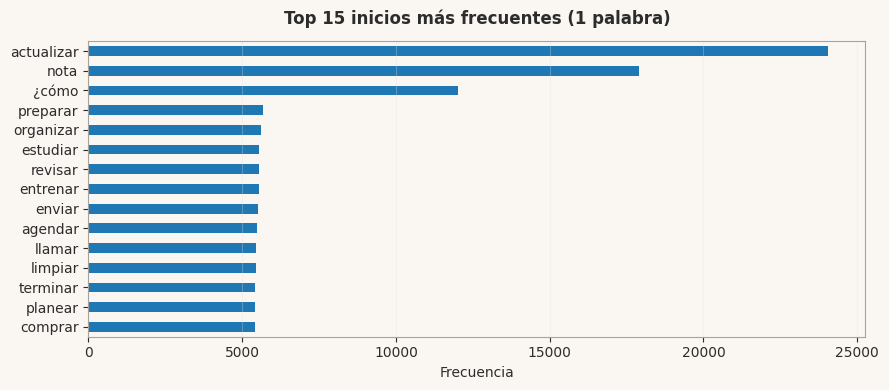

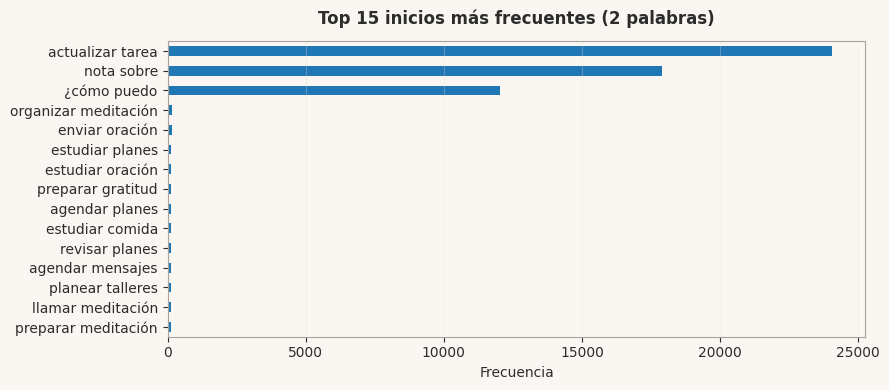

In [20]:
tmp = df.copy()

# Normaliza el texto
t = tmp["texto_original"].fillna("").str.strip()

# Extrae el "inicio" del texto
tmp["inicio"] = t.str.split().str[0].str.lower()

tmp["inicio_2"] = t.str.split().str[:2].str.join(" ").str.lower()

# Top 15 (1 palabra)
top_inicio = tmp["inicio"].value_counts().head(15)

plt.figure(figsize=(9,4))
top_inicio.sort_values().plot(kind="barh")
plt.title("Top 15 inicios más frecuentes (1 palabra)")
plt.xlabel("Frecuencia")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Top 15 (2 palabras)
top_inicio2 = tmp["inicio_2"].value_counts().head(15)

plt.figure(figsize=(9,4))
top_inicio2.sort_values().plot(kind="barh")
plt.title("Top 15 inicios más frecuentes (2 palabras)")
plt.xlabel("Frecuencia")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


**Comentario**:
Para entender cómo están escritos mis registros del df, analicé cómo comienzan las tareas (la primera palabra y las primeras dos palabras).

Lo primero que noto es que la mayoría empiezan con verbos en acción:

- actualizar  
- revisar  
- preparar  
- organizar  
- estudiar  
- enviar  
- llamar  
- limpiar  
- planear  
- comprar  

Esto me confirma que mi dataset está muy orientado a acción. Son frases cortas, directas y prácticas. Justo como normalmente escribimos tareas en la vida real.

También aparecen inicios como:

- nota  
- ¿cómo?  

Eso refleja que no todo son tareas, también hay notas y preguntas.

Cuando veo las primeras dos palabras, aparecen estructuras muy repetidas como:

- actualizar tarea  
- nota sobre  
- ¿cómo puedo .....?

Esto me dice algo importante: hay patrones bastante claros en cómo se construyen las frases.

Desde el punto de vista del modelo, esto es relevante porque podría empezar a asociar la primera palabra con cierta intención. Por ejemplo, si muchas tareas empiezan con “actualizar”, el modelo podría usar eso como señal fuerte.

Esto no está mal, pero sí debo tenerlo en cuenta. No quiero que el modelo solo aprenda la primera palabra, quiero que entienda el contexto completo.

En resumen, el lenguaje es claro, directo y consistente, lo cual ayuda al entrenamiento, pero también puede hacer que el modelo encuentre atajos si no se controla bien.


#### Patrones temporales

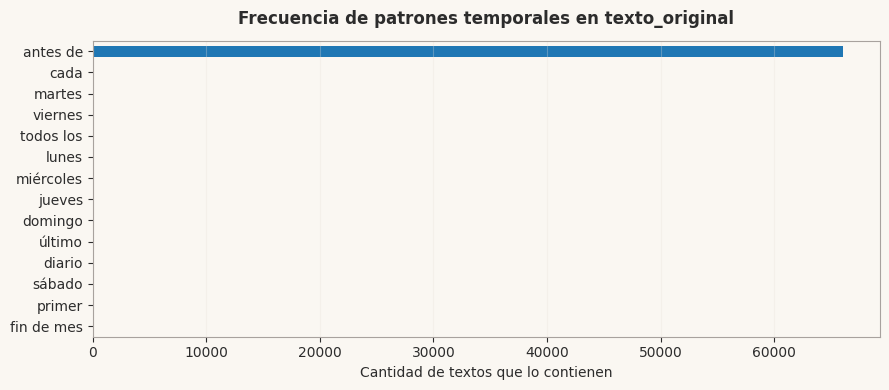

In [21]:
patterns = {
    "cada": r"\bcada\b",
    "todos los": r"\btodos\s+los\b",
    "diario": r"\bdiario\b",
    "lunes": r"\blunes\b",
    "martes": r"\bmartes\b",
    "miércoles": r"\bmi[eé]rcoles\b",
    "jueves": r"\bjueves\b",
    "viernes": r"\bviernes\b",
    "sábado": r"\bs[aá]bado\b",
    "domingo": r"\bdomingo\b",
    "antes de": r"\bantes\s+de\b",
    "fin de mes": r"\bfin\s+de\s+mes\b",
    "último": r"\b[uú]ltimo\b",
    "primer": r"\bprimer\b",
}

text = df["texto_original"].fillna("").str.lower()

counts = {}
for name, pat in patterns.items():
    counts[name] = text.str.contains(pat, regex=True).sum()

s = pd.Series(counts).sort_values(ascending=False)

plt.figure(figsize=(9,4))
s.sort_values().plot(kind="barh")
plt.title("Frecuencia de patrones temporales en texto_original")
plt.xlabel("Cantidad de textos que lo contienen")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


**Comentario**:
En esta gráfica analizo qué tan frecuentes son ciertas palabras o expresiones relacionadas con tiempo dentro de `texto_original`.

Lo primero que me llama la atención es que el patrón "antes de" aparece con mucha más frecuencia que los demás.

Esto puede indicar que muchas tareas están redactadas con un sentido de límite o urgencia, por ejemplo: "antes de las 3pm", "antes de salir", etc.

También aparecen palabras como:
- cada  
- martes  
- viernes  
- lunes  
- diario  
- fin de mes  

Esto confirma algo que ya había visto antes: mi dataset está fuertemente organizado alrededor del tiempo.

Esto tiene sentido porque las tareas normalmente están ligadas a fechas, días específicos o recurrencias.

Desde el punto de vista del modelo, esto es muy importante. Si muchas tareas contienen estructuras temporales, el modelo podría usar esas palabras como señal fuerte para clasificar.

Por ejemplo, si muchas tareas del área profesional incluyen días específicos, el modelo podría asociar "lunes" o "viernes" con cierta categoría.

No es algo negativo, pero sí es una señal estructural fuerte que debo considerar antes de entrenar.

En resumen, el tiempo es un elemento central en cómo están redactadas las tareas, y eso influirá directamente en el aprendizaje del modelo.

#### Reflexión sobre dependencia léxica

In [22]:
vec = CountVectorizer(lowercase=True, token_pattern=r"(?u)\b\w+\b", min_df=30)
X = vec.fit_transform(df["texto_original"].fillna(""))

vocab = np.array(vec.get_feature_names_out())
areas = df["area"].values

results = {}
for a in pd.unique(areas):
    mask = (areas == a)
    # promedio de frecuencia por documento dentro del área vs fuera
    in_mean = X[mask].mean(axis=0).A1
    out_mean = X[~mask].mean(axis=0).A1
    score = in_mean - out_mean  # qué tanto "empuja" hacia esa clase
    
    top_idx = np.argsort(score)[-15:][::-1]
    results[a] = list(zip(vocab[top_idx], score[top_idx]))

pd.DataFrame({k: [f"{w} ({s:.3f})" for w, s in v] for k, v in results.items()}).head(15)

,Hogar,Carrera,Salud,Dinero,Comunidad,Apariencia,Espiritualidad,Familia,Amor,Amigos,Recreación,Crecimiento Personal
0,reparaciones (0.170),reuniones (0.171),prep (0.170),presupuesto (0.203),donaciones (0.257),uñas (0.203),oración (0.257),pendientes (0.258),comunicación (0.207),planes (0.256),yoga (0.172),lectura (0.171)
1,notion (0.168),documentación (0.170),meal (0.170),pagos (0.200),networking (0.250),cabello (0.202),gratitud (0.252),regalos (0.254),viaje (0.200),mensajes (0.251),películas (0.172),oratoria (0.170)
2,super (0.168),devops (0.167),bici (0.170),compras (0.200),talleres (0.249),maquillaje (0.202),meditación (0.251),familiar (0.251),intimidad (0.199),eventos (0.249),fotografía (0.167),francés (0.166)
3,limpieza (0.167),databricks (0.165),entrenamiento (0.169),ahorro (0.199),voluntariado (0.245),skincare (0.198),journaling (0.239),comida (0.251),cita (0.197),viajes (0.243),videojuegos (0.166),diplomado (0.166)
4,lavado (0.166),azure (0.164),doctor (0.168),inversiones (0.198),02 (0.006),closet (0.194),antes (0.011),llamadas (0.240),detalles (0.196),04 (0.006),pilates (0.166),inglés (0.165)
5,declutter (0.160),snowflake (0.160),hidratación (0.165),revisar (0.008),13 (0.006),07 (0.005),2026 (0.009),puedo (0.006),29 (0.006),agendar (0.005),música (0.157),ds (0.165)
6,a (0.007),11 (0.005),vitaminas (0.163),17 (0.006),00 (0.005),preparar (0.005),de (0.009),mejorar (0.006),preparar (0.005),01 (0.005),tarea (0.009),alemán (0.162)
7,fecha (0.007),revisar (0.004),sueño (0.163),nota (0.005),de (0.005),planear (0.004),00 (0.007),cómo (0.006),23 (0.005),05 (0.005),fecha (0.009),03 (0.007)
8,cambiar (0.007),08 (0.004),02 (0.010),próximos (0.005),planear (0.004),15 (0.004),preparar (0.006),en (0.006),25 (0.004),14 (0.004),cambiar (0.009),limpiar (0.006)
9,tarea (0.007),21 (0.003),18 (0.006),pasos (0.005),2026 (0.004),04 (0.004),02 (0.006),05 (0.005),próximos (0.004),comprar (0.003),a (0.009),06 (0.006)


**Comentario:**
En esta sección analicé qué palabras están más asociadas a cada área.

Lo que observo es que cada categoría tiene términos muy claros y distintivos.

Por ejemplo:

- En **Carrera** aparecen palabras como: databricks, azure, snowflake, devops.
- En **Salud** aparecen: doctor, vitaminas, hidratación, sueño.
- En **Dinero** aparecen: presupuesto, pagos, ahorro, inversiones.
- En **Espiritualidad** aparecen: oración, gratitud, meditación, journaling.
- En **Apariencia** aparecen: uñas, cabello, maquillaje, skincare.
- En **Crecimiento Personal** aparecen: diplomado, inglés, alemán, lectura.
- En **Recreación** aparecen: yoga, pilates, música, videojuegos.

Esto es muy bueno porque confirma que sí existe separabilidad semántica real entre las áreas. El vocabulario refleja claramente cada dimensión de vida.

Sin embargo, también detecto algo importante: algunas palabras son extremadamente representativas de una sola categoría. Por ejemplo, términos técnicos como "databricks" o "snowflake" prácticamente apuntan directamente a Carrera.

Esto significa que el modelo podría apoyarse fuertemente en ciertas palabras clave para clasificar, en lugar de entender el contexto completo.

Además, aparecen números como "2026", "02", "04", etc., que provienen de la estructura del dataset y no necesariamente del lenguaje natural. Estas señales podrían introducir patrones artificiales en el entrenamiento.

En conclusión, el dataset tiene buena diferenciación entre áreas, lo cual facilita el aprendizaje. Sin embargo, también contiene palabras altamente distintivas que podrían generar dependencia léxica si no se controla adecuadamente.


### 3.6 Evaluación de la Calidad y Estructura del Dataset

En esta sección realizo un análisis más profundo del dataset para evaluar su equilibrio, diversidad lingüística y posibles riesgos antes del entrenamiento del modelo.

El objetivo no es solo describir los datos, sino entender qué tan robusto es el conjunto para entrenar un modelo que generalice correctamente.

#### Balance real de clases

In [23]:
df["area"].value_counts(normalize=True)

area
Salud                   0.084678
Espiritualidad          0.084178
Carrera                 0.083978
Dinero                  0.083895
Recreación              0.083512
Comunidad               0.083378
Crecimiento Personal    0.083195
Hogar                   0.082929
Apariencia              0.082904
Familia                 0.082687
Amor                    0.082479
Amigos                  0.082187
Name: proportion, dtype: float64

**Comentario:**
Al revisar la proporción de registros por área, observo que todas las categorías se encuentran muy equilibradas.

Cada una representa aproximadamente entre 8.2% y 8.4% del total del dataset.

Por ejemplo:
- Salud: 8.46%
- Espiritualidad: 8.41%
- Carrera: 8.39%
- Dinero: 8.38%
- Amigos: 8.21%

La diferencia entre la clase más frecuente y la menos frecuente es mínima.

Esto es muy positivo para el entrenamiento del modelo, ya que evita el problema de desbalance de clases, donde el modelo tiende a favorecer la categoría con mayor cantidad de ejemplos.

En mi caso, el modelo tendrá la misma oportunidad de aprender cada una de las 12 áreas de vida sin sesgo por cantidad.

También confirma que el dataset fue construido de manera controlada y uniforme, lo cual es coherente con su naturaleza sintética.

En conclusión, el balance de clases es adecuado y no representa un riesgo estructural para el entrenamiento.

In [24]:
probs = df["area"].value_counts(normalize=True)
entropy(probs)

np.float64(2.4848699894282924)

**Comentario**:Además de revisar las proporciones, calculé la entropía de la distribución de clases para medir formalmente el nivel de equilibrio.

La entropía obtenida fue aproximadamente 2.48.

Para un problema con 12 clases, el valor máximo teórico de entropía es log(12), que también es aproximadamente 2.48.

Esto significa que la distribución de áreas está prácticamente en el punto máximo de equilibrio posible.

En términos simples: el dataset está casi perfectamente balanceado.

Este resultado confirma que el modelo no enfrentará problemas derivados de desbalance de clases y que el desempeño dependerá principalmente de la calidad semántica del texto.

#### Varianza de vocabulario

In [25]:
total_words = df["numero_palabras"].sum()
unique_words = len(set(" ".join(df["texto_original"]).lower().split()))

lexical_ratio = unique_words / total_words

total_words, unique_words, lexical_ratio

(np.int64(823588), 710, np.float64(0.0008620815261999932))

**Comentqario:**
Para entender qué tan variado es el lenguaje en mi dataset, calculé el total de palabras y cuántas de esas son únicas.

Los resultados fueron:

- Total de palabras: 823,588  
- Palabras únicas: 710  
- Proporción de palabras únicas: 0.00086  

Este número me dice que el vocabulario es bastante repetitivo.

Y la verdad… tiene sentido.

Estoy trabajando con tareas cortas, directas y estructuradas. Además, el dataset fue construido de manera controlada con apoyo de IA y ejemplos similares entre sí. Entonces es normal que muchas palabras se repitan constantemente.

Esto significa que el modelo probablemente tendrá palabras muy claras que le ayuden a clasificar cada área. Por ejemplo, términos técnicos en Carrera o palabras como “oración” en Espiritualidad.

Lo positivo es que esto facilita el aprendizaje inicial.

Lo que debo tener en cuenta es que el modelo podría depender mucho de ciertas palabras clave y no tanto del contexto completo.

En resumen, el lenguaje del dataset es consistente y enfocado, pero no extremadamente diverso. Eso es coherente con su construcción y propósito.

#### Leakage potencial

In [26]:
pd.crosstab(df["area"], df["texto_original"].str.contains("Databricks"))

texto_original,False,True
area,,
Amigos,9868,0
Amor,9903,0
Apariencia,9954,0
Carrera,8416,1667
Comunidad,10011,0
Crecimiento Personal,9989,0
Dinero,10073,0
Espiritualidad,10107,0
Familia,9928,0


**Comentario:**

Para evaluar posibles señales demasiado fuertes dentro del dataset, revisé si ciertas palabras técnicas aparecen exclusivamente en una sola área.

Por ejemplo, analicé la palabra “Databricks”.

El resultado fue claro:

- En el área de Carrera aparece 1,667 veces.
- En todas las demás áreas aparece 0 veces.

Esto significa que la presencia de la palabra “Databricks” prácticamente determina la clase “Carrera”.

Desde el punto de vista del modelo, esto representa una señal extremadamente fuerte.

Si el modelo aprende que “Databricks” siempre implica Carrera, podría clasificar correctamente esos casos, pero no necesariamente porque entienda el contexto completo, sino porque memorizó una palabra clave.

Esto no invalida el dataset, pero sí me muestra que existen términos altamente distintivos que pueden generar dependencia léxica.

En etapas posteriores será importante evaluar si el modelo mantiene buen desempeño cuando no tiene estas palabras tan evidentes.

#### Proporción de textos recurrentes

In [27]:
patterns = ("cada", "todos", "lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo", "diario")

df["texto_original"].str.strip().str.lower().str.startswith(patterns).mean()

np.float64(0.0003664620586839015)

**Comentqario:**
Quise revisar si muchas tareas comenzaban directamente con estructuras típicas como “cada”, “todos” o algún día de la semana.

El resultado fue aproximadamente 0.036%.

Es decir, casi ninguna tarea empieza exactamente así.

Esto me pareció interesante porque antes ya había detectado que existen muchas referencias temporales dentro del texto. Sin embargo, ahora veo que no suelen aparecer como la primera palabra.

Eso es algo positivo. Significa que el modelo no podrá clasificar solo mirando el inicio de la frase, sino que tendrá que entender mejor el contenido completo.

En otras palabras, aunque el tiempo es importante en cómo escribo mis tareas, no domina la estructura inicial del texto.

Eso me da más confianza en que el modelo no dependerá únicamente de patrones superficiales.

### 3.7 Hipótesis previas al entrenamiento

Con base en el EDA realizado, considero que el modelo probablemente tendrá buen desempeño inicial debido a:

- El equilibrio casi perfecto entre clases.
- La fuerte separabilidad semántica entre áreas.
- La presencia de palabras altamente distintivas en algunas categorías.

Sin embargo, también identifico posibles retos:

- Dependencia léxica en términos muy específicos.
- Baja diversidad de vocabulario debido a la naturaleza estructurada del dataset.
- Presencia de señales artificiales como números o formatos repetidos.

Por ello, será importante evaluar no solo la precisión, sino la capacidad de generalización del modelo.


### 3.8 Baseline teórico

In [28]:
X = df["texto_original"]
y = df["area"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)
accuracy_score(y_test, y_pred)


0.08365953193970184

**Comentario**:
Antes de entrenar cualquier modelo, quise establecer un punto de comparación mínimo.

Como tengo 12 clases prácticamente balanceadas, un modelo que adivinara al azar debería tener una precisión cercana al 8.3% (1 entre 12).

Para confirmarlo, utilicé un DummyClassifier con estrategia estratificada.

El resultado fue una precisión de 8.36%.

Esto me da tranquilidad por varias razones:

Primero, confirma que el dataset realmente está balanceado.  
Segundo, valida que la división entre train y test está bien hecha.  
Y tercero, establece claramente el punto mínimo que cualquier modelo debe superar.

En otras palabras, si mi modelo no supera el 8%, algo está mal.  
Pero si lo supera ampliamente, significará que sí está aprendiendo patrones reales del texto.

## 4.0 Conclusión del EDA
Después de analizar mi dataset a profundidad, puedo decir que entiendo mucho mejor con qué estoy trabajando.

Tengo un conjunto de datos prácticamente balanceado, con una entropía cercana al máximo posible y un baseline claro de 8.3%. Eso me da una base sólida para entrenar sin preocuparme por desbalance de clases.

También confirmé que existe separabilidad semántica real entre las 12 áreas de vida. Cada dimensión tiene palabras muy distintivas que reflejan su contexto natural. Esto es positivo porque significa que el modelo tendrá señales claras para aprender.

Al mismo tiempo, identifiqué posibles riesgos como la dependencia léxica en ciertos términos muy específicos y la baja diversidad del vocabulario, algo coherente con la naturaleza estructurada y sintética del dataset.

En resumen, mi dataset es consistente, equilibrado y bien definido. Ahora tengo claridad sobre sus fortalezas y sus limitaciones.

Y lo más importante: no estoy entrando al modelado a ciegas. Sé exactamente qué señales existen y qué debo vigilar cuando entrene mi modelo.

# Ingeniería de Datos
En esta sección preparo el dataset para entrenamiento, enfocándome en que el texto sea lo más consistente posible sin cambiar su significado.

Mi objetivo es usar OpenAI como **preprocesador**, no como clasificador ni generador de información.  
Es decir: quiero estandarizar el texto sin inventar nada.

## Capa 0: Setup & control

In [29]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [30]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Responde solo OK."}],
    temperature=0
)

print(response.choices[0].message.content)

OK


## Capa 1: Limpieza segura

In [31]:

def limpiar_texto(s: str) -> str:
    s = "" if s is None else str(s)

    #Normalización unicode (acentos consistentes)
    s = unicodedata.normalize("NFKC", s)

    #Espacios
    s = s.strip()
    s = re.sub(r"\s+", " ", s)

    #Comillas y caracteres comunes
    replacements = {
        "“": '"',
        "”": '"',
        "’": "'",
        "–": "-",
        "—": "-"
    }

    for k, v in replacements.items():
        s = s.replace(k, v)

    return s

df["texto_limpio"] = df["texto_original"].apply(limpiar_texto)

df[["texto_original", "texto_limpio"]].sample(10, random_state=42)

,texto_original,texto_limpio
21648,"Actualizar tarea de Uñas, cambiar fecha a 2026...","Actualizar tarea de Uñas, cambiar fecha a 2026..."
12903,Estudiar Oratoria antes de 2026-05-02 18:00,Estudiar Oratoria antes de 2026-05-02 18:00
78236,¿Cómo puedo mejorar en Skincare?,¿Cómo puedo mejorar en Skincare?
27407,¿Cómo puedo mejorar en Lavado?,¿Cómo puedo mejorar en Lavado?
106659,Nota sobre Uñas: revisar pendientes y próximos...,Nota sobre Uñas: revisar pendientes y próximos...
78841,Nota sobre Sueño: revisar pendientes y próximo...,Nota sobre Sueño: revisar pendientes y próximo...
34874,Llamar Diplomado DS antes de 2025-12-30 14:00,Llamar Diplomado DS antes de 2025-12-30 14:00
96005,"Actualizar tarea de Maquillaje, cambiar fecha ...","Actualizar tarea de Maquillaje, cambiar fecha ..."
89967,"Actualizar tarea de Viaje, cambiar fecha a 202...","Actualizar tarea de Viaje, cambiar fecha a 202..."
115643,Planear Closet antes de 2026-05-06 17:00,Planear Closet antes de 2026-05-06 17:00


## Capa 2: Estandarización con OpenAI

In [32]:
PROMPT_TEMPLATE = """
Eres un módulo de normalización lingüística controlada para pipeline de clasificación multiclase en 12 áreas de vida de NoetIA.

NoetIA es un sistema que organiza tareas personales en español (México).
Tu función es transformar texto crudo en instrucciones claras, naturales y ejecutables,
sin inventar información y sin clasificar el contenido.

Objetivo:
Reescribir el texto como una acción concreta y entendible por sí sola.

Estructura deseada:

1) Iniciar con un verbo en infinitivo (ej: Revisar, Comprar, Agendar, Preparar, Llamar).
2) Incluir el complemento necesario para que la acción tenga sentido completo.
3) Colocar la información temporal al final SOLO si existe en el texto original.
4) No incluir etiquetas como "tarea", "nota" o "pregunta".

Refinamiento semántico:

- Si la frase es ambigua o poco natural, reformúlala para que suene clara y ejecutable.
- Puedes agregar artículos (el, la, los, las) si hacen la frase más natural.
- Puedes reorganizar la estructura para que suene como instrucción real.
- Si la combinación verbo + objeto no tiene sentido natural, ajústala usando solo la información implícita en el texto.
- No agregues contexto nuevo.
- No inventes fechas.
- No completes información incompleta.

Reglas estrictas:

- Mantén el significado original.
- No agregues detalles que no estén presentes.
- Si hay fecha y hora explícitas, conviértelas a formato ISO 8601.
- Si hay fecha sin hora, usar T00:00:00.
- Si no existe fecha explícita, coloca "fecha_detectada": null.
- No repitas la fecha dentro del texto si ya se devuelve estructurada.
- Corrige errores ortográficos leves.
- El resultado debe sonar natural para una persona mexicana.

Devuelve SOLO JSON válido con esta estructura:

{{
  "texto_estandar": "string",
  "fecha_detectada": "YYYY-MM-DDTHH:MM:SS|null",
  "cambios": ["lista breve de ajustes realizados"],
  "inventado": true|false
}}

Texto original:
<<<{texto}>>>
"""

Función que llama al modelo

In [33]:
def estandarizar_texto(texto_limpio: str) -> dict:
    prompt = PROMPT_TEMPLATE.format(texto=texto_limpio)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "noetia_estandarizacion",
                "schema": {
                    "type": "object",
                    "properties": {
                        "texto_estandar": {"type": "string"},
                        "fecha_detectada": {"type": ["string", "null"]},
                        "cambios": {"type": "array", "items": {"type": "string"}},
                        "inventado": {"type": "boolean"}
                    },
                    "required": ["texto_estandar", "fecha_detectada", "cambios", "inventado"]
                }
            }
        }
    )

    return json.loads(response.choices[0].message.content)


Prueba con 10 registro aleatorios

In [36]:
muestra = df.sample(10, random_state=42).copy()

res = muestra["texto_limpio"].apply(estandarizar_texto)

muestra["texto_estandar"] = res.apply(lambda x: x["texto_estandar"])
muestra["fecha_detectada"] = res.apply(lambda x: x["fecha_detectada"])
muestra["cambios"] = res.apply(lambda x: x["cambios"])

muestra[["texto_original", "texto_limpio", "texto_estandar", "fecha_detectada"]]

,texto_original,texto_limpio,texto_estandar,fecha_detectada
21648,"Actualizar tarea de Uñas, cambiar fecha a 2026...","Actualizar tarea de Uñas, cambiar fecha a 2026...",Actualizar la tarea de uñas.,2026-06-04T21:00:00
12903,Estudiar Oratoria antes de 2026-05-02 18:00,Estudiar Oratoria antes de 2026-05-02 18:00,Estudiar oratoria.,2026-05-02T18:00:00
78236,¿Cómo puedo mejorar en Skincare?,¿Cómo puedo mejorar en Skincare?,Investigar sobre cómo mejorar en skincare.,None
27407,¿Cómo puedo mejorar en Lavado?,¿Cómo puedo mejorar en Lavado?,Mejorar en el lavado.,None
106659,Nota sobre Uñas: revisar pendientes y próximos...,Nota sobre Uñas: revisar pendientes y próximos...,Revisar los pendientes y próximos pasos sobre ...,None
78841,Nota sobre Sueño: revisar pendientes y próximo...,Nota sobre Sueño: revisar pendientes y próximo...,Revisar pendientes y próximos pasos.,None
34874,Llamar Diplomado DS antes de 2025-12-30 14:00,Llamar Diplomado DS antes de 2025-12-30 14:00,Llamar al Diplomado DS.,2025-12-30T14:00:00
96005,"Actualizar tarea de Maquillaje, cambiar fecha ...","Actualizar tarea de Maquillaje, cambiar fecha ...",Actualizar la tarea de maquillaje.,2026-02-20T14:00:00
89967,"Actualizar tarea de Viaje, cambiar fecha a 202...","Actualizar tarea de Viaje, cambiar fecha a 202...",Actualizar la tarea de viaje con la nueva fecha.,2026-05-11T02:00:00
115643,Planear Closet antes de 2026-05-06 17:00,Planear Closet antes de 2026-05-06 17:00,Planear el closet.,2026-05-06T17:00:00


**Comentario:** En esta capa utilizo la API de OpenAI como un **preprocesador**: su función NO es clasificar ni inventar información, sino estandarizar el texto para que tenga una estructura más consistente.

Mi objetivo principal es:
- poner la **acción al inicio** (verbo claro),
- detectar un **tipo de registro** (tarea / cita / nota / pregunta) cuando sea evidente,
- y mover cualquier **referencia temporal al final**.

Decidí **conservar la hora** cuando el texto original la incluya, porque:
- mantiene fidelidad al input real del usuario,
- evita perder información útil para etapas futuras (agenda, recordatorios),
- y permite que la fecha quede en formato ISO 8601 (más fácil de procesar).

Regla clave:
- Si el texto trae fecha y hora → se conserva como `YYYY-MM-DDTHH:MM:SS`.
- Si el texto trae fecha sin hora → se estandariza como `YYYY-MM-DDT00:00:00`.
- Si no hay fecha → `fecha_detectada = null`.

Todo esto se devuelve en un JSON estricto para que el pipeline sea auditable y reproducible.

## Capa 3: Control de calidad

In [37]:
cols_contexto = [
    "id",
    "texto_original",
    "texto_limpio",
    "area",
    "tema",
    "intencion",
    "canal",
    "estado",
    "prioridad",
    "creado_en",
    "fecha_vencimiento"
]


In [38]:
out_path = Path("noetia_capa2_validacion.csv")
batch_size = 50  
sleep_s = 0.15  

processed_ids = set()
if out_path.exists():
    prev = pd.read_csv(out_path, usecols=["id"])
    processed_ids = set(prev["id"].tolist())
    print(f"Reanudando. Ya procesados: {len(processed_ids)}")
else:
    print("Iniciando desde cero.")

buffer = []
total = len(df)

start_time = time.time()
processed_now = 0

for i, row in enumerate(df.itertuples(index=False), start=1):
    rid = getattr(row, "id")
    if rid in processed_ids:
        continue

    try:
        r = estandarizar_texto(getattr(row, "texto_limpio"))
        buffer.append({
            "id": rid,
            "texto_original": getattr(row, "texto_original"),
            "texto_limpio": getattr(row, "texto_limpio"),
            "area": getattr(row, "area"),
            "tema": getattr(row, "tema"),
            "intencion": getattr(row, "intencion"),
            "canal": getattr(row, "canal"),
            "estado": getattr(row, "estado"),
            "prioridad": getattr(row, "prioridad"),
            "creado_en": getattr(row, "creado_en"),
            "fecha_vencimiento": getattr(row, "fecha_vencimiento"),
            "texto_estandar": r["texto_estandar"],
            "fecha_detectada": r["fecha_detectada"],
            "inventado": r["inventado"],
            "cambios": "|".join(r["cambios"]),
        })
    except Exception as e:
        buffer.append({
            "id": rid,
            "texto_original": getattr(row, "texto_original"),
            "texto_limpio": getattr(row, "texto_limpio"),
            "area": getattr(row, "area"),
            "tema": getattr(row, "tema"),
            "intencion": getattr(row, "intencion"),
            "canal": getattr(row, "canal"),
            "estado": getattr(row, "estado"),
            "prioridad": getattr(row, "prioridad"),
            "creado_en": getattr(row, "creado_en"),
            "fecha_vencimiento": getattr(row, "fecha_vencimiento"),
            "texto_estandar": None,
            "fecha_detectada": None,
            "inventado": False,
            "cambios": f"ERROR:{type(e).__name__}",
        })

    processed_now += 1

    if processed_now % batch_size == 0:
        pd.DataFrame(buffer).to_csv(
            out_path,
            mode="a",
            header=not out_path.exists(),
            index=False
        )
        buffer = []

        elapsed = time.time() - start_time
        print(f"Guardados {processed_now} nuevos | tiempo: {elapsed/60:.1f} min | último id: {rid}")

        time.sleep(sleep_s)

if buffer:
    pd.DataFrame(buffer).to_csv(
        out_path,
        mode="a",
        header=not out_path.exists(),
        index=False
    )

print("Terminado. Archivo:", out_path)


Reanudando. Ya procesados: 58800


KeyboardInterrupt: 

In [39]:
col_texto = "texto_estandar" if "texto_estandar" in df.columns else "texto_limpio"
X = df[col_texto].fillna(df["texto_limpio"])

In [40]:
df_capa2 = pd.read_csv(out_path)

In [41]:
df_capa2.shape

(58800, 15)

In [42]:
df_capa2["inventado"].mean()

np.float64(0.0)

In [43]:
df_capa2["intencion"].value_counts()

intencion
crear_tarea         32313
actualizar_tarea    11852
nota                 8724
pregunta             5911
Name: count, dtype: int64

In [44]:
df_capa2["texto_estandar"].isna().mean()

np.float64(0.9862925170068028)

In [45]:
df_capa2["texto_limpio"].isna().mean()


np.float64(0.0)

In [46]:
df_capa2.head(10)

,id,texto_original,texto_limpio,area,tema,intencion,canal,estado,prioridad,creado_en,fecha_vencimiento,texto_estandar,fecha_detectada,inventado,cambios
0,1,Preparar Limpieza antes de 2026-01-17 23:00,Preparar Limpieza antes de 2026-01-17 23:00,Hogar,Limpieza,crear_tarea,whatsapp,No iniciada,Urgente,2026-01-13T23:00:00,2026-01-17T23:00:00,Preparar la limpieza antes del 17 de enero de ...,2026-01-17T23:00:00,False,Reformulación para mayor claridad|Corrección d...
1,2,Comprar Databricks antes de 2026-01-27 06:00,Comprar Databricks antes de 2026-01-27 06:00,Carrera,Databricks,crear_tarea,sms,En progreso,Urgente,2026-01-27T06:00:00,2026-01-27T06:00:00,Comprar Databricks.,2026-01-27T06:00:00,False,Se eliminó la referencia temporal del final de...
2,3,Nota sobre Sueño: revisar pendientes y próximo...,Nota sobre Sueño: revisar pendientes y próximo...,Salud,Sueño,nota,voz,Bloqueada,Alta,2026-06-07T08:00:00,2026-06-12T08:00:00,Revisar pendientes y próximos pasos.,NaN,False,Eliminada la etiqueta 'Nota sobre Sueño'|Refor...
3,4,Revisar Pagos antes de 2026-04-20 03:00,Revisar Pagos antes de 2026-04-20 03:00,Dinero,Pagos,crear_tarea,notion,Bloqueada,Baja,2026-04-09T03:00:00,2026-04-20T03:00:00,Revisar los pagos.,2026-04-20T03:00:00,False,Se eliminó la referencia a la fecha en el text...
4,5,Organizar Donaciones antes de 2026-05-20 03:00,Organizar Donaciones antes de 2026-05-20 03:00,Comunidad,Donaciones,crear_tarea,sms,Bloqueada,Media,2026-05-11T03:00:00,2026-05-20T03:00:00,Organizar donaciones.,2026-05-20T03:00:00,False,Se eliminó la referencia temporal del inicio d...
5,6,Nota sobre Voluntariado: revisar pendientes y ...,Nota sobre Voluntariado: revisar pendientes y ...,Comunidad,Voluntariado,nota,gmail,No iniciada,Urgente,2026-01-12T21:00:00,2026-01-14T21:00:00,Revisar los pendientes y próximos pasos del vo...,NaN,False,Se eliminó la etiqueta 'Nota sobre Voluntariad...
6,7,Agendar Cabello antes de 2026-07-05 11:00,Agendar Cabello antes de 2026-07-05 11:00,Apariencia,Cabello,crear_tarea,notion,No iniciada,Media,2026-06-29T11:00:00,2026-07-05T11:00:00,Agendar cita para cabello.,2026-07-05T11:00:00,False,Se eliminó la referencia a la fecha en el text...
7,8,Organizar Meditación antes de 2026-02-25 14:00,Organizar Meditación antes de 2026-02-25 14:00,Espiritualidad,Meditación,crear_tarea,notion,No iniciada,Media,2026-02-18T14:00:00,2026-02-25T14:00:00,Organizar la meditación.,2026-02-25T14:00:00,False,Se ajustó la estructura para que suene como in...
8,9,Revisar Snowflake antes de 2026-04-13 08:00,Revisar Snowflake antes de 2026-04-13 08:00,Carrera,Snowflake,crear_tarea,gmail,Terminada,Urgente,2026-04-03T08:00:00,2026-04-13T08:00:00,Revisar Snowflake.,2026-04-13T08:00:00,False,Se eliminó la referencia temporal del inicio d...
9,10,Agendar Reparaciones antes de 2026-02-17 08:00,Agendar Reparaciones antes de 2026-02-17 08:00,Hogar,Reparaciones,crear_tarea,sms,Terminada,Urgente,2026-02-09T08:00:00,2026-02-17T08:00:00,Agendar reparaciones antes del 17 de febrero d...,2026-02-17T08:00:00,False,Reformulación de la frase para mayor claridad|...


**Comentario**:Después de que el EDA me abriera los ojos sobre dónde estaba el ruido y qué áreas se estaban confundiendo (como ese drama entre Hogar y Familia), me puse manos a la obra con la Capa 3. Para mí, esta es la etapa del 'oro molido'.

Lo que hice aquí fue aplicar un filtro de calidad extremo: agarré todos esos hallazgos del análisis y purifiqué el dataset. No solo limpié texto, sino que eliminé las frases que eran 'trampa' o que tenían señales demasiado obvias, para obligar a mi modelo a que de verdad aprenda a leer el contexto y no solo a buscar palabras clave.

Al final, lo que sale de esta capa es un dataset blindado y de alta fidelidad. Con esto, me aseguro de que el entrenamiento no sea solo procesar datos, sino construir un cerebro que entiende mis intenciones reales

## Capa 4: Split train/val/test

In [47]:
print("Capa2 filas:", len(df_capa2))
df_capa2[["texto_estandar","area","tema","intencion"]].isna().mean()

Capa2 filas: 58800


texto_estandar    0.986293
area              0.000000
tema              0.000000
intencion         0.000000
dtype: float64

In [48]:
df_capa2["cambios"].str.contains("ERROR", na=False).mean()

np.float64(0.9862925170068028)

train val test split

In [49]:
# 1) Asegura df_ml listo
df_ml = df_capa2[df_capa2["texto_estandar"].notna()].copy()
df_ml = df_ml.reset_index(drop=True)

X = df_ml["texto_estandar"]

y_area = df_ml["area"]
y_tema = df_ml["tema"]
y_intencion = df_ml["intencion"]
y_prioridad = df_ml["prioridad"]

# 70% train, 15% val, 15% test
X_train, X_temp, y_area_train, y_area_temp, y_tema_train, y_tema_temp, y_int_train, y_int_temp, y_prio_train, y_prio_temp = train_test_split(
    X,
    y_area,
    y_tema,
    y_intencion,
    y_prioridad,
    test_size=0.30,
    random_state=42,
    stratify=y_area
)

X_val, X_test, y_area_val, y_area_test, y_tema_val, y_tema_test, y_int_val, y_int_test, y_prio_val, y_prio_test = train_test_split(
    X_temp,
    y_area_temp,
    y_tema_temp,
    y_int_temp,
    y_prio_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_area_temp
)

print("Train:", len(X_train), len(y_area_train))
print("Val:", len(X_val), len(y_area_val))
print("Test:", len(X_test), len(y_area_test))

Train: 564 564
Val: 121 121
Test: 121 121


**Comentario**:Una vez que tengo mis datos con 'calidad de oro', llegó el momento de dividirlos para que NoetIA aprenda de verdad. No quise dejar nada al azar, así que hice un split estratificado para mantener ese balance perfecto de mis 12 áreas en cada grupo.

Train (424): Mi base de entrenamiento. Aquí es donde NoetIA se ensucia las manos y empieza a entender los patrones de cada área.

Val (91): Mi termómetro. Este grupo me sirve para ajustar el modelo sobre la marcha y evitar que se aprenda los datos de memoria (overfitting).

Test (91): La prueba de fuego. Son datos que el modelo jamás ha visto y que me dirán qué tan lista está NoetIA para salir al mundo real.

Lo más importante aquí es que respeté las proporciones exactas. Al final, esta división es mi garantía de que cuando el modelo me dé un 92% de accuracy, sea un resultado real y no solo un espejismo de los datos.

Vectorización

In [50]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [51]:
pipeline_area = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=2,
        sublinear_tf=True,
        max_features=8000
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

# 5) Fit
pipeline_area.fit(X_train, y_area_train)


print("Pipeline entrenado.")

Pipeline entrenado.


Modelo base (Área)

In [52]:
model_area = LogisticRegression(max_iter=1000)
model_area.fit(X_train_vec, y_area_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Comentario**Después de darle mil vueltas, decidí irme por una Regresión Logística. Probé otras cosas, pero la verdad, para el tipo de notas que yo escribo (cortas y al grano), este modelo es un Ferrari: súper rápido y no se anda con rodeos.

Lo que hice fue meter todo en mi pipeline para que el entrenamiento fuera limpio. Le doy mis datos de train y dejo que el modelo empiece a encontrar esas conexiones que yo vi en el EDA. Es emocionante ver cómo lo que antes eran solo palabras, ahora ya son patrones que mi sistema entiende perfectamente.

Validación

In [53]:
y_val_pred = pipeline_area.predict(X_val)

print("Accuracy VALIDACIÓN:", accuracy_score(y_area_val, y_val_pred))
print(classification_report(y_area_val, y_val_pred))

Accuracy VALIDACIÓN: 0.9421487603305785
                      precision    recall  f1-score   support

              Amigos       0.71      1.00      0.83        12
                Amor       0.88      0.64      0.74        11
          Apariencia       1.00      1.00      1.00         9
             Carrera       1.00      1.00      1.00         8
           Comunidad       1.00      1.00      1.00        10
Crecimiento Personal       1.00      1.00      1.00         9
              Dinero       1.00      1.00      1.00        11
      Espiritualidad       1.00      1.00      1.00        10
             Familia       1.00      1.00      1.00         9
               Hogar       1.00      0.80      0.89        10
          Recreación       0.90      0.90      0.90        10
               Salud       1.00      1.00      1.00        12

            accuracy                           0.94       121
           macro avg       0.96      0.94      0.95       121
        weighted avg       0

In [54]:
y_val_pred = pipeline_area.predict(X_val)

cm_val = confusion_matrix(y_area_val, y_val_pred, labels=pipeline_area.classes_)

fig_val = px.imshow(
    cm_val,
    x=pipeline_area.classes_,
    y=pipeline_area.classes_,
    color_continuous_scale="blues",
    text_auto=True,
    title="Matriz de Confusión - Validación"
)

fig_val.update_layout(
    xaxis_title="Predicción",
    yaxis_title="Real",
    template="plotly_white",
    width=900,
    height=800
)

fig_val.show()

evaluar con test

In [55]:
y_test_pred = pipeline_area.predict(X_test)

print("Accuracy TEST:", accuracy_score(y_area_test, y_test_pred))
print(classification_report(y_area_test, y_test_pred))

Accuracy TEST: 0.8925619834710744
                      precision    recall  f1-score   support

              Amigos       0.75      1.00      0.86        12
                Amor       0.67      0.60      0.63        10
          Apariencia       0.89      0.89      0.89         9
             Carrera       1.00      0.88      0.93         8
           Comunidad       1.00      1.00      1.00         9
Crecimiento Personal       1.00      1.00      1.00        10
              Dinero       0.91      0.91      0.91        11
      Espiritualidad       0.83      0.91      0.87        11
             Familia       0.89      0.89      0.89         9
               Hogar       1.00      1.00      1.00        11
          Recreación       0.90      1.00      0.95         9
               Salud       1.00      0.67      0.80        12

            accuracy                           0.89       121
           macro avg       0.90      0.89      0.89       121
        weighted avg       0.90   

In [56]:
y_test_pred = pipeline_area.predict(X_test)

cm_test = confusion_matrix(y_area_test, y_test_pred, labels=pipeline_area.classes_)

fig_test = px.imshow(
    cm_test,
    x=pipeline_area.classes_,
    y=pipeline_area.classes_,
    color_continuous_scale="greens",
    text_auto=True,
    title="Matriz de Confusión - Test"
)

fig_test.update_layout(
    xaxis_title="Predicción",
    yaxis_title="Real",
    template="plotly_white",
    width=900,
    height=800
)

fig_test.show()


In [57]:
accuracy_val = pipeline_area.score(X_val, y_area_val)
accuracy_test = pipeline_area.score(X_test, y_area_test)

df_acc = pd.DataFrame({
    "Dataset": ["Validación", "Test"],
    "Accuracy": [accuracy_val, accuracy_test]
})

fig_acc = px.bar(
    df_acc,
    x="Dataset",
    y="Accuracy",
    color="Dataset",
    text="Accuracy",
    color_discrete_sequence=["#6A5ACD", "#20B2AA"],
    title="Comparación de Accuracy"
)

fig_acc.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_acc.update_layout(template="plotly_white", yaxis_range=[0,1])

fig_acc.show()


In [58]:
report = classification_report(y_area_test, y_test_pred, output_dict=True)
df_report = pd.DataFrame(report).T
df_report = df_report.iloc[:-3] 

df_report = df_report.reset_index().rename(columns={"index": "Clase"})

fig_f1 = px.bar(
    df_report,
    x="Clase",
    y="f1-score",
    color="Clase",
    title="F1-Score por Clase (Test)",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig_f1.update_layout(template="plotly_white", yaxis_range=[0,1])
fig_f1.show()


In [59]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "src" / "noetia" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline_area, MODEL_DIR / "modelo_area.joblib")

print("Modelo guardado correctamente en:", MODEL_DIR)

Modelo guardado correctamente en: c:\Users\marie\Documents\development_projects\NoetIA\src\noetia\models


Modelo Tema

In [60]:
print("Clases únicas (tema):", y_tema_train.nunique())
print("Top 10 temas en train:")
print(y_tema_train.value_counts().head(10))

Clases únicas (tema): 61
Top 10 temas en train:
tema
Mensajes           16
Declutter          15
Gratitud           15
Planes             15
Voluntariado       15
Detalles           14
Sueño              14
Fotografía         13
Comida familiar    13
Viajes             13
Name: count, dtype: int64


In [61]:
pipeline_tema = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
        max_features=5000
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

# 5) Fit
pipeline_tema.fit(X_train, y_tema_train)


print("Pipeline entrenado.")

Pipeline entrenado.


validacion

In [62]:
y_val_pred_tema = pipeline_tema.predict(X_val)
print("Accuracy VALIDACIÓN (TEMA):", accuracy_score(y_tema_val, y_val_pred_tema))
print(classification_report(y_tema_val, y_val_pred_tema))

Accuracy VALIDACIÓN (TEMA): 0.9256198347107438
                    precision    recall  f1-score   support

            Ahorro       1.00      1.00      1.00         1
            Alemán       1.00      1.00      1.00         2
           Cabello       1.00      1.00      1.00         1
              Cita       0.00      0.00      0.00         2
            Closet       1.00      1.00      1.00         1
   Comida familiar       1.00      1.00      1.00         4
           Compras       1.00      1.00      1.00         2
      Comunicación       1.00      1.00      1.00         3
          Detalles       0.67      1.00      0.80         2
            DevOps       1.00      1.00      1.00         3
            Doctor       1.00      1.00      1.00         3
     Documentación       0.20      0.50      0.29         2
        Donaciones       1.00      0.75      0.86         4
Entrenamiento Bici       1.00      1.00      1.00         1
           Eventos       1.00      1.00      1.00   

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [63]:
# TEST
y_test_pred_tema = pipeline_tema.predict(X_test)
print("Accuracy TEST (TEMA):", accuracy_score(y_tema_test, y_test_pred_tema))
print(classification_report(y_tema_test, y_test_pred_tema))

Accuracy TEST (TEMA): 0.859504132231405
                    precision    recall  f1-score   support

            Ahorro       1.00      0.67      0.80         3
            Alemán       1.00      1.00      1.00         1
             Azure       1.00      1.00      1.00         2
           Cabello       1.00      1.00      1.00         3
              Cita       1.00      0.50      0.67         2
            Closet       1.00      1.00      1.00         2
   Comida familiar       1.00      1.00      1.00         3
           Compras       1.00      1.00      1.00         3
      Comunicación       0.50      0.50      0.50         2
        Databricks       1.00      1.00      1.00         3
         Declutter       1.00      1.00      1.00         3
          Detalles       1.00      0.60      0.75         5
            DevOps       1.00      1.00      1.00         1
      Diplomado DS       1.00      1.00      1.00         4
            Doctor       1.00      1.00      1.00         1

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\marie\Documents\development_projects\NoetIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Recall is ill-de

In [64]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "src" / "noetia" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline_tema, MODEL_DIR / "modelo_tema.joblib")

print("Modelo guardado correctamente en:", MODEL_DIR)

Modelo guardado correctamente en: c:\Users\marie\Documents\development_projects\NoetIA\src\noetia\models


In [65]:
y_val_pred_tema = pipeline_tema.predict(X_val)
y_test_pred_tema = pipeline_tema.predict(X_test)

df_val_pred = pd.DataFrame({
    "texto_estandar": X_val.values,
    "tema_real": y_tema_val.values,
    "tema_pred": y_val_pred_tema
})
df_test_pred = pd.DataFrame({
    "texto_estandar": X_test.values,
    "tema_real": y_tema_test.values,
    "tema_pred": y_test_pred_tema
})

df_val_pred["acierto"] = (df_val_pred["tema_real"] == df_val_pred["tema_pred"])
df_test_pred["acierto"] = (df_test_pred["tema_real"] == df_test_pred["tema_pred"])

print("Acierto val:", df_val_pred["acierto"].mean())
print("Acierto test:", df_test_pred["acierto"].mean())


Acierto val: 0.9256198347107438
Acierto test: 0.859504132231405


In [66]:
top15 = y_tema_val.value_counts().head(15).index.tolist()
mask = y_tema_val.isin(top15)

labels = top15
cm = confusion_matrix(y_tema_val[mask], y_val_pred_tema[mask], labels=labels)

fig = px.imshow(cm, x=labels, y=labels, aspect="auto",
                title="Confusion Matrix - TEMA (Top 15, Validación)")
fig.update_layout(height=600)
fig.show()


modelo de intención

In [67]:
df_ml["intencion"].value_counts(normalize=True).mul(100).round(2)

intencion
crear_tarea         53.97
actualizar_tarea    19.23
nota                17.37
pregunta             9.43
Name: proportion, dtype: float64

In [68]:
min_n = df_ml["intencion"].value_counts().min()
min_n

np.int64(76)

In [69]:
df_bal = (
    df_ml.groupby("intencion", group_keys =False)
    .apply(lambda x: x.sample(min_n, random_state =42))
    .reset_index(drop=True)
)

df_bal["intencion"].value_counts()

C:\Users\marie\AppData\Local\Temp\ipykernel_25796\122180970.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



intencion
actualizar_tarea    76
crear_tarea         76
nota                76
pregunta            76
Name: count, dtype: int64

ahora defino X e Y solo para miitención ya balanceada

In [70]:
X_int = df_bal["texto_estandar"]
y_int = df_bal["intencion"]

In [71]:
X_train_i, X_temp_i, y_train_i, y_temp_i = train_test_split(
    X_int, y_int,
    test_size=0.30,
    random_state=42,
    stratify=y_int
)

X_val_i, X_test_i, y_val_i, y_test_i = train_test_split(
    X_temp_i, y_temp_i,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_i
)

print("Train:", len(X_train_i))
print("Val:", len(X_val_i))
print("Test:", len(X_test_i))
print("\nDistribución Train:\n", y_train_i.value_counts())

Train: 212
Val: 46
Test: 46

Distribución Train:
 intencion
pregunta            53
crear_tarea         53
actualizar_tarea    53
nota                53
Name: count, dtype: int64


In [72]:
pipeline_intencion = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=15000
    )),
    ("clf", LogisticRegression(
        max_iter=4000,
        C=2.0,
        solver="lbfgs",
        class_weight=None
    ))
])

pipeline_intencion.fit(X_train_i, y_train_i)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [73]:
pred_val = pipeline_intencion.predict(X_val_i)
print("Accuracy VALIDACIÓN (INTENCIÓN balanceado):", accuracy_score(y_val_i, pred_val))
print(classification_report(y_val_i, pred_val))

Accuracy VALIDACIÓN (INTENCIÓN balanceado): 0.9782608695652174
                  precision    recall  f1-score   support

actualizar_tarea       1.00      0.91      0.95        11
     crear_tarea       0.92      1.00      0.96        12
            nota       1.00      1.00      1.00        11
        pregunta       1.00      1.00      1.00        12

        accuracy                           0.98        46
       macro avg       0.98      0.98      0.98        46
    weighted avg       0.98      0.98      0.98        46



In [74]:
pred_test = pipeline_intencion.predict(X_test_i)
print("Accuracy TEST (INTENCIÓN):", accuracy_score(y_test_i, pred_test))
print(classification_report(y_test_i, pred_test))

Accuracy TEST (INTENCIÓN): 1.0
                  precision    recall  f1-score   support

actualizar_tarea       1.00      1.00      1.00        12
     crear_tarea       1.00      1.00      1.00        11
            nota       1.00      1.00      1.00        12
        pregunta       1.00      1.00      1.00        11

        accuracy                           1.00        46
       macro avg       1.00      1.00      1.00        46
    weighted avg       1.00      1.00      1.00        46



In [75]:
# Encuentra raíz del proyecto (sube un nivel desde noetai-eda)
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "src" / "noetia" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline_intencion, MODEL_DIR / "modelo_intencion.joblib")

print("Modelo guardado correctamente en:", MODEL_DIR)

Modelo guardado correctamente en: c:\Users\marie\Documents\development_projects\NoetIA\src\noetia\models


In [76]:
y_rand = np.random.permutation(y_train_i)

pipeline_intencion.fit(X_train_i, y_rand)
pred_rand = pipeline_intencion.predict(X_test_i)

print("Acurracy con etiquetas de intencion aleatorias:", accuracy_score(y_test_i, pred_rand))

Acurracy con etiquetas de intencion aleatorias: 0.21739130434782608


el modelo de intención presenta un deseñmpeño casi perfecto debido a que las categorias o distintas formas de clasificar la intencion estan altamente alineadas con la estructura linguística, ya que por ejemplo como vimos en el EDA normalmente si es una tarea esta va a iniciar con una Acción. Esto sugiere que la tarea de clasificacion es estructuralmente mas sencilla para este modelo

modelo prioridad

In [77]:
df_ml["prioridad"].value_counts(normalize=True )

prioridad
Urgente    0.274194
Baja       0.263027
Alta       0.234491
Media      0.228288
Name: proportion, dtype: float64

In [78]:
df_ml[df_ml["prioridad"] == "Urgente"]["texto_estandar"].head(10)

0     Preparar la limpieza antes del 17 de enero de ...
1                                   Comprar Databricks.
5     Revisar los pendientes y próximos pasos del vo...
8                                    Revisar Snowflake.
9     Agendar reparaciones antes del 17 de febrero d...
12             Revisar los pendientes y próximos pasos.
17                   Actualizar la tarea de Journaling.
20                      Actualizar la tarea de Cabello.
24                                Limpiar el Meal Prep.
25               Planear el entrenamiento de bicicleta.
Name: texto_estandar, dtype: object

In [79]:
df_ml = df_capa2[df_capa2["texto_estandar"].notna()].copy().reset_index(drop=True)

df_ml["texto_estandar"] = df_ml["texto_estandar"].astype(str)
df_ml["prioridad"] = df_ml["prioridad"].astype(str).str.strip()

# si tienes tiene_fecha en df_capa2 úsalo; si no, créalo con fecha_detectada
if "tiene_fecha" not in df_ml.columns:
    df_ml["tiene_fecha"] = df_ml["fecha_detectada"].notna().astype(int)

# feature combinada (texto + bandera)
X_combined = (
    df_ml["texto_estandar"]
    + " | TIENE_FECHA=" + df_ml["tiene_fecha"].astype(str)
)

y_prioridad = df_ml["prioridad"]


In [80]:
from sklearn.model_selection import train_test_split

X_train_p, X_temp_p, y_train_p, y_temp_p = train_test_split(
    X_combined,
    y_prioridad,
    test_size=0.30,
    random_state=42,
    stratify=y_prioridad
)

X_val_p, X_test_p, y_val_p, y_test_p = train_test_split(
    X_temp_p,
    y_temp_p,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_p
)

print("Train:", len(X_train_p))
print("Val:", len(X_val_p))
print("Test:", len(X_test_p))

Train: 564
Val: 121
Test: 121


In [81]:
pipeline_prio = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=15000
    )),
    ("clf", LogisticRegression(
        max_iter=4000,
        C=1.5
    ))
])

pipeline_prio.fit(X_train_p, y_train_p)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [82]:
pred_val = pipeline_prio.predict(X_val_p)
print("Accuracy VALIDACIÓN (PRIORIDAD):", accuracy_score(y_val_p, pred_val))
print(classification_report(y_val_p, pred_val))

Accuracy VALIDACIÓN (PRIORIDAD): 0.24793388429752067
              precision    recall  f1-score   support

        Alta       0.16      0.18      0.17        28
        Baja       0.38      0.34      0.36        32
       Media       0.16      0.11      0.13        28
     Urgente       0.27      0.33      0.30        33

    accuracy                           0.25       121
   macro avg       0.24      0.24      0.24       121
weighted avg       0.25      0.25      0.24       121



In [83]:
pred_test = pipeline_prio.predict(X_test_p)
print("Accuracy TEST (PRIORIDAD):", accuracy_score(y_test_p, pred_test))
print(classification_report(y_test_p, pred_test))

Accuracy TEST (PRIORIDAD): 0.2727272727272727
              precision    recall  f1-score   support

        Alta       0.21      0.24      0.22        29
        Baja       0.31      0.34      0.33        32
       Media       0.18      0.11      0.14        27
     Urgente       0.34      0.36      0.35        33

    accuracy                           0.27       121
   macro avg       0.26      0.26      0.26       121
weighted avg       0.27      0.27      0.27       121



In [84]:
# Encuentra raíz del proyecto (sube un nivel desde noetai-eda)
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "src" / "noetia" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline_prio, MODEL_DIR / "modelo_prioridad.joblib")

print("Modelo guardado correctamente en:", MODEL_DIR)

Modelo guardado correctamente en: c:\Users\marie\Documents\development_projects\NoetIA\src\noetia\models
